### 注意核心问题
上游问题的λ，和下游问题中的λ要对齐，否则无法进行有效的梯度传递。



## 1. 配置

In [ ]:
RAW_PATH   = 'D:/investment/Data/hs300_factor_data_filled.parquet'
PANEL_PATH = 'D:/investment/Data/factor_panel_v2_processed.parquet'
IC_PATH    = 'D:/investment/Data/03v3_ic_summary.csv'

IC_TSTAT_THRESHOLD = 2.0
MIN_COVERAGE       = 0.70
FWD_RET_COVERAGE   = 0.80
HIDDEN_DIM = 32
SEED       = 42

N_WARM     = 10
N_E2E      = 60
LR_MSE     = 1e-3
LR_E2E     = 1e-4
GRAD_CLIP  = 1.0
BATCH_SIZE = 8

# ── ★ 风险偏好参数（Section 4.4）──────────────────────────────────────────
LAMBDA      = 1.0                          # 单次默认值
LAMBDA_LIST = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]  # 多 λ 扫描

# ── ★ SOCP 层参数 ─────────────────────────────────────────────────────────
# ZETA_TRAIN: 内层 QP 的 L2 平滑项（技术项，确保梯度流）
#   作用：使 w_i* 连续可微，不影响 λ 的经济含义
#   推荐：ZETA_TRAIN ≈ λ × mean(var_i)，约 0.007~0.07，不宜太大
ZETA_TRAIN = 10.0    # SOCP 内层的 L2 平滑（远小于 v4 的10，因为风险项已提供梯度）
ALPHA_IC   = 0.05   # IC 辅助损失权重

MAX_W_FRAC = 10     # max_w = 10/N
TC_RATE    = 0.003
TRAIN_WINDOW = 36
STEP_SIZE    = 3

print("="*60)
print(f"  LAMBDA      = {LAMBDA}   (单次默认，论文 η)")
print(f"  ZETA_TRAIN  = {ZETA_TRAIN}   (SOCP L2平滑，技术项，非风险惩罚)")
print(f"  ALPHA_IC    = {ALPHA_IC}")
print(f"  内层 QP: -μᵀw + λ√(wᵀDw) + ζ/2·‖w‖²  (★ 含风险项，与Eq.21对齐)")
print(f"  外层loss: -(w*ᵀr - λ·√(w*ᵀDw*))          (Mean-SD效用)")

  LAMBDA      = 1.0   (单次默认，论文 η)
  ZETA_TRAIN  = 10.0   (SOCP L2平滑，技术项，非风险惩罚)
  ALPHA_IC    = 0.05
  内层 QP: -μᵀw + λ√(wᵀDw) + ζ/2·‖w‖²  (★ 含风险项，与Eq.21对齐)
  外层loss: -(w*ᵀr - λ·√(w*ᵀDw*))          (Mean-SD效用)


## 2. 导入与数据加载

In [12]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings, time
from collections import Counter
from scipy.optimize import brentq
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F

torch.manual_seed(SEED); np.random.seed(SEED)
plt.rcParams['font.sans-serif'] = ['SimHei','Arial Unicode MS','DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

panel = pd.read_parquet(PANEL_PATH)
panel['date'] = pd.to_datetime(panel['date'])
ic_df = pd.read_csv(IC_PATH, index_col=0)
if 'Sig(|t|>2)' in ic_df.columns:    sig_mask = ic_df['Sig(|t|>2)']
elif 't_stat' in ic_df.columns:       sig_mask = ic_df['t_stat'].abs() > IC_TSTAT_THRESHOLD
else: raise ValueError("IC 文件需含 t_stat 或 Sig(|t|>2) 列")
SIG_FACTORS = list(ic_df[sig_mask].index); N_FEATURES = len(SIG_FACTORS)
print(f"Factor panel: {panel.shape}  ({panel['date'].nunique()} months)")
print(f"显著因子 ({N_FEATURES} 个): {SIG_FACTORS}")
assert N_FEATURES >= 2

Factor panel: (21760, 105)  (68 months)
显著因子 (10 个): ['F91_ocf_ni', 'F97_accruals', 'F80_ocf_mv', 'F74_cfp', 'F55_holding_adj', 'F81_size', 'F34_vol_of_vol', 'F88_cash_roe', 'F41_turn_std', 'F30_range_vol']


## 3. 股票池 & 特征

In [13]:
all_dates = sorted(panel['date'].unique())
def get_valid_stocks(df, factors):
    return set(df.dropna(subset=factors + ['fwd_ret'])['ts_code'].unique())
month_valid = {d: get_valid_stocks(panel[panel['date']==d], SIG_FACTORS) for d in all_dates}
stock_cnt = Counter(s for v in month_valid.values() for s in v)
universe  = sorted(s for s,c in stock_cnt.items() if c/len(all_dates) >= MIN_COVERAGE)
N = len(universe); MAX_W = MAX_W_FRAC / N

panel_u = (panel[panel['ts_code'].isin(universe)].sort_values(['date','ts_code']).reset_index(drop=True))
for col in SIG_FACTORS:
    panel_u[col] = panel_u.groupby('date')[col].transform(
        lambda x: x.fillna(0 if x.isna().all() else x.mean()))
panel_u['fwd_ret'] = panel_u.groupby('date')['fwd_ret'].transform(
    lambda x: x.fillna(x.median() if not x.isna().all() else 0))
def cross_sec_zscore(arr):
    mu = arr.mean(0,keepdims=True); sig = np.maximum(arr.std(0,keepdims=True),1e-8)
    return np.nan_to_num((arr-mu)/sig).astype('float32')
fwd_cov = panel_u.groupby('date')['fwd_ret'].apply(lambda x: x.notna().mean())
dates_valid = [d for d in sorted(panel_u['date'].unique()) if fwd_cov.get(d,0) >= FWD_RET_COVERAGE]
X_tensors, y_tensors = [], []
for d in dates_valid:
    sub = panel_u[panel_u['date']==d].sort_values('ts_code')
    X_tensors.append(torch.tensor(cross_sec_zscore(sub[SIG_FACTORS].values)))
    y_tensors.append(torch.tensor(sub['fwd_ret'].values.astype('float32')))
T = len(X_tensors)
print(f"股票池: {N} 只   max_w = {MAX_W_FRAC}/N = {MAX_W:.4f}  有效月份: {T}")

股票池: 252 只   max_w = 10/N = 0.0397  有效月份: 68


## 4. 滚动窗口

In [14]:
rolling_windows = []
start = 0
while start + TRAIN_WINDOW + STEP_SIZE <= T:
    rolling_windows.append({'train_start':start,'train_end':start+TRAIN_WINDOW,
                             'test_start':start+TRAIN_WINDOW,
                             'test_end':min(start+TRAIN_WINDOW+STEP_SIZE,T)})
    start += STEP_SIZE
assert rolling_windows
fw, lw = rolling_windows[0], rolling_windows[-1]
print(f"滚动窗口: {len(rolling_windows)} 个")
print(f"首: [{dates_valid[fw['train_start']].date()}~{dates_valid[fw['train_end']-1].date()}] → [{dates_valid[fw['test_start']].date()}~{dates_valid[fw['test_end']-1].date()}]")
print(f"末: 测试 [{dates_valid[lw['test_start']].date()}~{dates_valid[lw['test_end']-1].date()}]")

滚动窗口: 10 个
首: [2020-04-30~2023-03-31] → [2023-04-28~2023-06-30]
末: 测试 [2025-07-31~2025-09-30]


## 5. 可微 SOCP 层（v5b 核心）

**与 v4/v5 的本质区别：**
- v4/v5 LP 层内层：$\min -\mu^\top w + \frac{\zeta}{2}\|w\|^2$（只有平滑项）
- **v5b SOCP 层内层：$\min -\mu^\top w + \lambda\sqrt{w^\top Dw} + \frac{\zeta}{2}\|w\|^2$**（含真实风险项）


In [15]:
# ── SOCP 前向求解器（固定点迭代）────────────────────────────────────────
def solve_socp_diag(mu_np, var_np, lambda_, max_w, zeta, max_iter=40, tol=1e-9):
    """
    求解: min_w  -μᵀw + λ·√(wᵀDw) + (ζ/2)·‖w‖²
          s.t.   Σwᵢ=1, 0 ≤ wᵢ ≤ max_w
    其中 D = diag(var_np).

    固定点迭代（每步用 brentq，通常 4-6 次收敛）：
      给定 P = √(wᵀDw)，per-stock 有效 ζᵢ = λσᵢ²/P + ζ
      wᵢ = clip((μᵢ − ν*) / ζᵢ_eff, 0, max_w)
      更新 P ← √(Σᵢ σᵢ² wᵢ²)，重复至 P 收敛。
    """
    n = len(mu_np)
    # 初始化 P：用纯 L2 平滑 LP 的解
    z0 = max(zeta, 1e-6)
    def lp_budget(nu): return np.clip((mu_np-nu)/z0, 0, max_w).sum()-1.0
    try:
        nu0 = brentq(lp_budget, mu_np.min()-max_w*z0-1, mu_np.max()+1, xtol=1e-10, maxiter=200)
        w0  = np.clip((mu_np-nu0)/z0, 0, max_w); w0 /= max(w0.sum(), 1e-10)
    except:
        w0 = np.ones(n) / n
    P = max(np.sqrt((w0**2 * var_np).sum()), 1e-8)

    w = w0.copy()
    for _ in range(max_iter):
        eff_z = lambda_ * var_np / P + zeta          # per-stock effective ζᵢ (>0)
        def budget(nu): return np.clip((mu_np-nu)/eff_z, 0, max_w).sum()-1.0
        nu_lo = (mu_np - eff_z*max_w).max() - 1.0
        nu_hi = mu_np.max() + 1.0
        try:
            nu    = brentq(budget, nu_lo, nu_hi, xtol=1e-10, maxiter=300)
            w_new = np.clip((mu_np-nu)/eff_z, 0, max_w)
            s     = w_new.sum(); w_new = w_new/s if s>1e-10 else np.ones(n)/n
        except:
            break
        P_new = max(np.sqrt((w_new**2 * var_np).sum()), 1e-8)
        if abs(P_new - P) < tol:
            w, P = w_new, P_new; break
        w, P = w_new, P_new
    return w, P


# ── KKT 反传（SOCP + L2 平滑，对应论文 Eq.12-13 的扩展）─────────────────
class SOCPSmoothFunction(torch.autograd.Function):
    """
    Forward : 固定点迭代求解 SOCP（含真实风险项 λ√(wᵀDw)）
    Backward: KKT 隐函数定理

    KKT 矩阵（自由变量集 F）:
      K = [[H_F - (λ/P*)·α_F·α_Fᵀ,  e_F],
           [e_Fᵀ,                      0 ]]
    其中:
      H_F = diag(λσᵢ²/P* + ζ)_{i∈F}   (SOCP + L2 联合 Hessian)
      α_F = (σᵢ²·wᵢ*/P*)_{i∈F}         (portfolio risk attribution)
      rank-1 修正来自 ∂P/∂w 的链式法则
    """

    @staticmethod
    def forward(ctx, mu, var, lambda_, max_w, zeta):
        n      = mu.shape[0]
        mu_np  = mu.detach().numpy().astype(np.float64)
        var_np = var.detach().numpy().astype(np.float64)

        w_np, P = solve_socp_diag(mu_np, var_np, lambda_, max_w, zeta)
        eps  = 1e-6
        free = (w_np > eps) & (w_np < max_w - eps)

        ctx.save_for_backward(torch.tensor(w_np, dtype=mu.dtype),
                              torch.tensor(var_np, dtype=mu.dtype))
        ctx.P       = P
        ctx.lambda_ = lambda_
        ctx.zeta    = zeta
        ctx.free    = free
        ctx.n       = n
        return torch.tensor(w_np, dtype=mu.dtype)

    @staticmethod
    def backward(ctx, grad_output):
        (w_star, var_t) = ctx.saved_tensors
        P, lambda_, zeta = ctx.P, ctx.lambda_, ctx.zeta
        free, n = ctx.free, ctx.n
        n_free  = int(free.sum())

        if n_free == 0:
            return torch.zeros(n, dtype=torch.float32), None, None, None, None

        free_idx = np.where(free)[0]
        w_F   = w_star.numpy()[free_idx]
        var_F = var_t.numpy()[free_idx]

        # H_F = diag(λσᵢ²/P + ζ)  — SOCP + L2 联合 Hessian
        H_diag = lambda_ * var_F / P + zeta

        # α_F = σᵢ²·wᵢ*/P  — risk attribution vector
        alpha_F = var_F * w_F / P

        # K = [[H_F - (λ/P)·αα', e]; [e', 0]]
        K = np.zeros((n_free+1, n_free+1))
        K[:n_free, :n_free] = (np.diag(H_diag)
                                - (lambda_ / P) * np.outer(alpha_F, alpha_F))
        K[:n_free,  n_free] = 1.0
        K[ n_free, :n_free] = 1.0

        try:
            K_inv = np.linalg.solve(K, np.eye(n_free+1))
        except np.linalg.LinAlgError:
            K_inv = np.linalg.lstsq(K, np.eye(n_free+1), rcond=None)[0]

        dw_dmu  = K_inv[:n_free, :n_free]
        grad_np = grad_output.numpy().astype(np.float64)
        grad_mu = np.zeros(n)
        grad_mu[free_idx] = dw_dmu @ grad_np[free_idx]

        return torch.tensor(grad_mu, dtype=torch.float32), None, None, None, None


class DifferentiableSOCP(nn.Module):
    """可微 SOCP 层，接受 (mu, var_vec) 两个输入"""
    def __init__(self, max_w, lambda_, zeta):
        super().__init__()
        self.max_w, self.lambda_, self.zeta = max_w, lambda_, zeta

    def forward(self, mu, var):
        return SOCPSmoothFunction.apply(mu, var, self.lambda_, self.max_w, self.zeta)


# ── 梯度流验证 ───────────────────────────────────────────────────────────
print("=== 梯度流验证（SOCP v5b）===")
torch.manual_seed(0)
_mlp = nn.Sequential(nn.Linear(N_FEATURES,32), nn.ReLU(), nn.Linear(32,1))
_X, _y = X_tensors[10], y_tensors[10]

# 估计方差（用前20月）
_var_np = np.stack([y_tensors[i].numpy() for i in range(20)]).var(axis=0)
_var_np = np.maximum(_var_np, 1e-6).astype('float32')
_var_t  = torch.tensor(_var_np)

for lam, label in [(LAMBDA, f"λ={LAMBDA}(SOCP+L2)"), (0.0, "λ=0(纯L2,对照)")]:
    _socp = DifferentiableSOCP(max_w=MAX_W, lambda_=lam, zeta=ZETA_TRAIN)
    _mu   = _mlp(_X).squeeze(-1)
    _w    = _socp(_mu, _var_t)
    loss  = -(_w * _y).sum()
    loss.backward()
    norms  = [p.grad.norm().item() if p.grad is not None else 0 for p in _mlp.parameters()]
    _free  = int(((_w.detach()>1e-6) & (_w.detach()<MAX_W-1e-6)).sum())
    port_std = float(torch.sqrt((_w.detach()**2 * _var_t).sum()))
    print(f"  {label}: free={_free}/{N}  port_std={port_std:.4f}  grad={[f'{v:.2e}' for v in norms]}")
    print(f"    {'✓ 梯度正常' if all(v>0 for v in norms) else '⚠ 部分梯度为零'}")
    for p in _mlp.parameters():
        if p.grad is not None: p.grad.zero_()
del _mlp, _X, _y, _mu, _w, loss, _var_t, _var_np

=== 梯度流验证（SOCP v5b）===
  λ=1.0(SOCP+L2): free=134/252  port_std=0.0170  grad=['4.22e-01', '8.85e-02', '5.52e-01', '0.00e+00']
    ⚠ 部分梯度为零
  λ=0(纯L2,对照): free=118/252  port_std=0.0198  grad=['4.03e-01', '8.07e-02', '5.17e-01', '0.00e+00']
    ⚠ 部分梯度为零


## 6. 模型定义

In [16]:
class CrossSectionalMLP(nn.Module):
    def __init__(self, n_features=N_FEATURES, hidden=HIDDEN_DIM):
        super().__init__()
        h2 = max(hidden//2, 4)
        self.net = nn.Sequential(
            nn.LayerNorm(n_features),
            nn.Linear(n_features,hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(hidden,h2),         nn.BatchNorm1d(h2),     nn.ReLU(), nn.Dropout(0.05),
            nn.Linear(h2, 1))
    def forward(self, X): return self.net(X).squeeze(-1)

_tmp = CrossSectionalMLP()
print(f"模型参数: {sum(p.numel() for p in _tmp.parameters())}"); del _tmp

模型参数: 1013


## 7. 训练函数（v5b：内层 QP 含风险项，与 Eq.21 对齐）

In [17]:
def compute_var_vec(y_tr_list):
    mat = np.stack([y.numpy() for y in y_tr_list])
    return np.maximum(mat.var(axis=0), 1e-6).astype('float32')


def train_e2e_v5b(model, X_tr, y_tr, var_vec, lambda_,
                   n_warm, n_e2e, lr_mse, lr_e2e,
                   grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    """
    v5b 训练函数（论文 Eq.21 完整实现，忽略 TC）

    内层 QP（训练）: min -μᵀw + λ√(wᵀDw) + ζ/2‖w‖²
    外层 loss:       -(w*ᵀr - λ·√(w*ᵀDw*))   ← Mean-SD 效用
    IC 辅助:         -α_IC · Pearson(μ_hat, r) ← 全股梯度补充

    内层 QP（测试）: min -μᵀw + λ√(wᵀD_t w)  （ZETA_TRAIN=0，还原论文原意）
    """
    T_tr   = len(X_tr)
    var_t  = torch.tensor(var_vec, dtype=torch.float32)
    # ★ SOCP 层：内层 QP 含真实风险项 λ√(wᵀDw) + ζ 平滑
    socp_train = DifferentiableSOCP(max_w=MAX_W, lambda_=lambda_, zeta=ZETA_TRAIN)
    hist   = {'mse':[], 'e2e':[], 'free_vars':[]}

    # Phase 1: MSE 预热（所有股票得到梯度，让 mu_hat 先有方向）
    opt = optim.Adam(model.parameters(), lr=lr_mse)
    for ep in range(n_warm):
        model.train(); ep_loss = 0.0
        for bs in range(0, T_tr, batch_size):
            be = min(bs+batch_size,T_tr); opt.zero_grad()
            bl = sum(F.mse_loss(model(X_tr[t]), y_tr[t]) for t in range(bs,be))
            (bl/(be-bs)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step(); ep_loss += bl.item()/(be-bs)
        hist['mse'].append(ep_loss/max(1,T_tr//batch_size))

    # Phase 2: E2E Mean-SD（内层含风险项 → 梯度更准确体现风险偏好）
    opt = optim.Adam(model.parameters(), lr=lr_e2e)
    for ep in range(n_e2e):
        model.train(); ep_loss=0.0; n_batches=0; ep_free=0
        for bs in range(0, T_tr, batch_size):
            be = min(bs+batch_size,T_tr); opt.zero_grad()
            bl = torch.tensor(0.0)
            for t in range(bs, be):
                mu_hat = model(X_tr[t])

                # ★ 内层 SOCP（含风险项，与论文 Eq.21 一致）
                try:
                    w_star = socp_train(mu_hat, var_t)
                except Exception:
                    w_star = (torch.ones(N)/N).detach()

                # 外层 loss = -(均值 - λ·标准差)
                port_ret = (w_star * y_tr[t]).sum()
                port_std = torch.sqrt((w_star**2 * var_t).sum() + 1e-8)
                e2e_loss_t = -(port_ret - lambda_ * port_std)

                # IC 辅助（补充全股梯度，防止 free-var 以外的股票完全失去更新信号）
                if ALPHA_IC > 0:
                    mu_c = mu_hat - mu_hat.mean()
                    y_c  = (y_tr[t] - y_tr[t].mean()).detach()
                    ic_t = (mu_c*y_c).sum() / (mu_c.norm()*y_c.norm()+1e-8)
                    e2e_loss_t = e2e_loss_t - ALPHA_IC * ic_t

                bl = bl + e2e_loss_t
                with torch.no_grad():
                    _w = w_star.detach()
                    ep_free += int(((_w>1e-6)&(_w<MAX_W-1e-6)).sum())

            avg = bl/(be-bs); avg.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step(); ep_loss+=avg.item(); n_batches+=1

        hist['e2e'].append(ep_loss/max(n_batches,1))
        hist['free_vars'].append(ep_free/max(T_tr,1))
    return hist


def train_mse_v5b(model, X_tr, y_tr, n_epochs, lr,
                   grad_clip=GRAD_CLIP, batch_size=BATCH_SIZE):
    T_tr=len(X_tr); hist=[]; opt=optim.Adam(model.parameters(), lr=lr)
    for ep in range(n_epochs):
        model.train(); ep_loss=0.0
        for bs in range(0,T_tr,batch_size):
            be=min(bs+batch_size,T_tr); opt.zero_grad()
            bl=sum(F.mse_loss(model(X_tr[t]),y_tr[t]) for t in range(bs,be))
            (bl/(be-bs)).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step(); ep_loss+=bl.item()/(be-bs)
        hist.append(ep_loss/max(1,T_tr//batch_size))
    return hist

print("训练函数 v5b 定义完毕")
print(f"  内层 QP: -μᵀw + λ√(wᵀDw) + ζ/2‖w‖²  (λ={LAMBDA}, ζ={ZETA_TRAIN})")

训练函数 v5b 定义完毕
  内层 QP: -μᵀw + λ√(wᵀDw) + ζ/2‖w‖²  (λ=1.0, ζ=10.0)


## 8. 滚动运行器（v5b）

In [18]:
def run_rolling_v5b(mode, lambda_=LAMBDA):
    assert mode in ('e2e','mse')
    res = {'returns':[],'weights':[],'dates':[],'bench':[],'free_vars':[],'loss_curves':[]}
    w_prev = (torch.ones(N)/N).detach()
    t0 = time.time()

    for idx, win in enumerate(rolling_windows):
        ts,te = win['train_start'],win['train_end']
        vs,ve = win['test_start'], win['test_end']
        X_tr  = [X_tensors[i] for i in range(ts,te)]
        y_tr  = [y_tensors[i] for i in range(ts,te)]

        # 每窗口从训练集估计对角方差
        var_vec = compute_var_vec(y_tr)
        var_t   = torch.tensor(var_vec, dtype=torch.float32)

        torch.manual_seed(SEED + idx*37)
        model_w = CrossSectionalMLP()

        if mode == 'e2e':
            hist = train_e2e_v5b(model_w, X_tr, y_tr, var_vec, lambda_,
                                  N_WARM, N_E2E, LR_MSE, LR_E2E)
            final_loss    = hist['e2e'][-1] if hist['e2e'] else float('nan')
            avg_train_free = hist['free_vars'][-1] if hist['free_vars'] else 0
            res['loss_curves'].append(hist['e2e'])
        else:
            hist = train_mse_v5b(model_w, X_tr, y_tr, N_WARM+N_E2E, LR_MSE)
            final_loss = hist[-1]; avg_train_free = 0
            res['loss_curves'].append(hist)

        # ── 样本外测试：SOCP 层（ZETA=0，还原论文原始风险调整权重）──────────
        # 注意：v5b 测试不用 lp_test，而是 SOCP（内含风险项，与训练一致）
        model_w.eval()
        socp_test = DifferentiableSOCP(max_w=MAX_W, lambda_=lambda_, zeta=0.0)
        n_free_sum = 0
        for i in range(vs, ve):
            with torch.no_grad():
                mu_hat = model_w(X_tensors[i])
            # 估计测试期方差：用最近 TRAIN_WINDOW 月的训练数据
            # （实际中应用 t 时刻之前的数据；此处近似用本窗口训练集）
            try:
                w = socp_test(mu_hat, var_t).detach()
            except Exception:
                w = torch.ones(N)/N
            n_free = int(((w>1e-6)&(w<MAX_W-1e-6)).sum()); n_free_sum+=n_free
            tc_cost = TC_RATE * (w - w_prev).abs().sum().item()
            res['returns'].append((w * y_tensors[i]).sum().item() - tc_cost)
            res['weights'].append(w.numpy()); res['dates'].append(dates_valid[i])
            res['bench'].append(y_tensors[i].mean().item()); res['free_vars'].append(n_free)
            w_prev = w

        avg_test_free = n_free_sum / max(ve-vs, 1)
        print(f"  [{mode.upper()} λ={lambda_}] win{idx+1:02d}/{len(rolling_windows)}"
              f"  [{dates_valid[ts].strftime('%y-%m')}~{dates_valid[te-1].strftime('%y-%m')}]"
              f"  → [{dates_valid[vs].strftime('%y-%m')}~{dates_valid[ve-1].strftime('%y-%m')}]"
              f"  loss={final_loss:+.4f}  tr_free={avg_train_free:.1f}  te_free={avg_test_free:.1f}"
              f"  {(time.time()-t0)/60:.1f}min")
    return res

print("滚动运行器 v5b 定义完毕")

滚动运行器 v5b 定义完毕


## 9. 执行实验

In [19]:
print("="*70)
print(f"E2E v5b  (内层 QP 含风险项 λ={LAMBDA}，与论文 Eq.21 完全对齐)")
print("="*70)
res_e2e = run_rolling_v5b('e2e', lambda_=LAMBDA)

print()
print("="*70)
print("MSE Baseline（相同窗口，公平对比）")
print("="*70)
res_mse = run_rolling_v5b('mse')

E2E v5b  (内层 QP 含风险项 λ=1.0，与论文 Eq.21 完全对齐)
  [E2E λ=1.0] win01/10  [20-04~23-03]  → [23-04~23-06]  loss=-0.0269  tr_free=84.6  te_free=11.7  2.5min
  [E2E λ=1.0] win02/10  [20-07~23-06]  → [23-07~23-09]  loss=-0.0185  tr_free=81.6  te_free=10.0  4.0min
  [E2E λ=1.0] win03/10  [20-10~23-09]  → [23-10~23-12]  loss=-0.0107  tr_free=82.2  te_free=7.7  5.7min
  [E2E λ=1.0] win04/10  [21-01~23-12]  → [24-01~24-03]  loss=+0.0007  tr_free=80.3  te_free=6.7  7.2min
  [E2E λ=1.0] win05/10  [21-04~24-03]  → [24-04~24-06]  loss=-0.0128  tr_free=90.1  te_free=8.0  10.0min
  [E2E λ=1.0] win06/10  [21-07~24-06]  → [24-07~24-09]  loss=-0.0112  tr_free=78.1  te_free=7.7  10.6min
  [E2E λ=1.0] win07/10  [21-10~24-09]  → [24-10~24-12]  loss=-0.0154  tr_free=106.6  te_free=7.0  12.4min
  [E2E λ=1.0] win08/10  [22-01~24-12]  → [25-01~25-03]  loss=-0.0048  tr_free=101.6  te_free=10.3  15.7min
  [E2E λ=1.0] win09/10  [22-04~25-03]  → [25-04~25-06]  loss=-0.0097  tr_free=95.0  te_free=8.7  18.0min
  [E2E λ=1.

## 10. 业绩汇总（含换手率）

In [20]:
def calc_turnover(weights_list):
    to=[]; w_prev=np.ones(N)/N
    for w in weights_list: to.append(np.abs(w-w_prev).sum()); w_prev=w
    return np.array(to)

def metrics(returns, weights_list, label='', verbose=True):
    r       = np.array(returns)
    ann_ret = r.mean()*12; ann_vol = r.std(ddof=1)*np.sqrt(12)
    sharpe  = ann_ret/ann_vol if ann_vol>0 else 0
    cum     = np.cumprod(1+r); dd = (cum/np.maximum.accumulate(cum))-1
    neg     = r[r<0]
    sortino = ann_ret/(neg.std()*np.sqrt(12)) if len(neg)>1 else float('nan')
    win     = (r>0).mean()
    to      = calc_turnover(weights_list) if weights_list is not None else np.array([0.0])
    avg_to  = to.mean()
    if verbose:
        print(f"{label:<20}  AnnRet={ann_ret:+.2%}  AnnVol={ann_vol:.2%}"
              f"  SR={sharpe:.3f}  Sortino={sortino:.3f}"
              f"  MDD={dd.min():.2%}  Win={win:.1%}  AvgTO={avg_to:.2%}")
    return dict(Ann_Ret=ann_ret, Ann_Vol=ann_vol, Sharpe=sharpe,
                Sortino=sortino, MDD=dd.min(), Win=win, AvgTO=avg_to)

r_e2e   = np.array(res_e2e['returns'])
r_mse   = np.array(res_mse['returns'])
r_bench = np.array(res_e2e['bench'])

print("\n"+"="*78)
print(f"测试期业绩汇总（λ={LAMBDA}，已扣 TC=0.3%）")
print("="*78)
m_e2e   = metrics(r_e2e,   res_e2e['weights'], f'E2E v5b (λ={LAMBDA})')
m_mse   = metrics(r_mse,   res_mse['weights'], 'MSE Baseline       ')
m_bench = metrics(r_bench, None,               'Equal-Weight       ')

diff_r = m_e2e['Ann_Ret']-m_mse['Ann_Ret']
diff_s = m_e2e['Sharpe'] -m_mse['Sharpe']
diff_t = m_e2e['AvgTO']  -m_mse['AvgTO']
print(f"\nE2E vs MSE: 年化收益差 {diff_r:+.2%}  Sharpe差 {diff_s:+.3f}  换手率差 {diff_t:+.2%}")
print(f"  {'✓ E2E 胜出！' if diff_r > 0 else '✗ MSE 仍领先'}")

for lbl,res in [('e2e_v5b',res_e2e),('mse_v5b',res_mse)]:
    pd.DataFrame(np.array(res['weights']),
                 index=[d.strftime('%Y-%m') for d in res['dates']],
                 columns=universe).to_csv(f'./weights_{lbl}.csv', encoding='utf-8-sig')
print("\n权重已保存")


测试期业绩汇总（λ=1.0，已扣 TC=0.3%）
E2E v5b (λ=1.0)       AnnRet=+27.31%  AnnVol=24.16%  SR=1.131  Sortino=4.620  MDD=-12.24%  Win=56.7%  AvgTO=113.39%
MSE Baseline          AnnRet=+15.23%  AnnVol=23.55%  SR=0.646  Sortino=1.797  MDD=-20.46%  Win=40.0%  AvgTO=138.55%
Equal-Weight          AnnRet=+10.67%  AnnVol=20.30%  SR=0.525  Sortino=1.471  MDD=-17.30%  Win=46.7%  AvgTO=0.00%

E2E vs MSE: 年化收益差 +12.09%  Sharpe差 +0.484  换手率差 -25.16%
  ✓ E2E 胜出！

权重已保存


## 11. 多 λ 扫描（可选，耗时较长）

In [21]:
# 如果只想看单次结果，可跳过此 Cell
print("="*65)
print(f"多 λ 扫描: {LAMBDA_LIST}  (每次 ≈ 单次耗时)")
print("="*65)

sweep_results = {}
for lam in LAMBDA_LIST:
    print(f"\n── λ = {lam} ──")
    _res = run_rolling_v5b('e2e', lambda_=lam)
    _m   = metrics(np.array(_res['returns']), _res['weights'],
                   label=f'E2E v5b λ={lam}', verbose=True)
    _m['lambda'] = lam
    sweep_results[lam] = {'res': _res, 'metrics': _m}

sweep_results['MSE'] = {'res': res_mse, 'metrics': {**m_mse, 'lambda': None}}
print("\n多 λ 扫描完毕")

多 λ 扫描: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]  (每次 ≈ 单次耗时)

── λ = 0.1 ──
  [E2E λ=0.1] win01/10  [20-04~23-03]  → [23-04~23-06]  loss=-0.0506  tr_free=65.5  te_free=1.7  1.3min
  [E2E λ=0.1] win02/10  [20-07~23-06]  → [23-07~23-09]  loss=-0.0380  tr_free=70.7  te_free=2.0  2.0min
  [E2E λ=0.1] win03/10  [20-10~23-09]  → [23-10~23-12]  loss=-0.0281  tr_free=73.9  te_free=2.0  2.8min
  [E2E λ=0.1] win04/10  [21-01~23-12]  → [24-01~24-03]  loss=-0.0142  tr_free=71.0  te_free=2.3  3.6min
  [E2E λ=0.1] win05/10  [21-04~24-03]  → [24-04~24-06]  loss=-0.0293  tr_free=74.2  te_free=2.0  4.4min
  [E2E λ=0.1] win06/10  [21-07~24-06]  → [24-07~24-09]  loss=-0.0276  tr_free=63.7  te_free=1.3  4.8min
  [E2E λ=0.1] win07/10  [21-10~24-09]  → [24-10~24-12]  loss=-0.0340  tr_free=79.4  te_free=1.7  5.9min
  [E2E λ=0.1] win08/10  [22-01~24-12]  → [25-01~25-03]  loss=-0.0209  tr_free=86.4  te_free=1.7  6.8min
  [E2E λ=0.1] win09/10  [22-04~25-03]  → [25-04~25-06]  loss=-0.0271  tr_free=76.4  te_free=1.0  7.8

## 12. 可视化

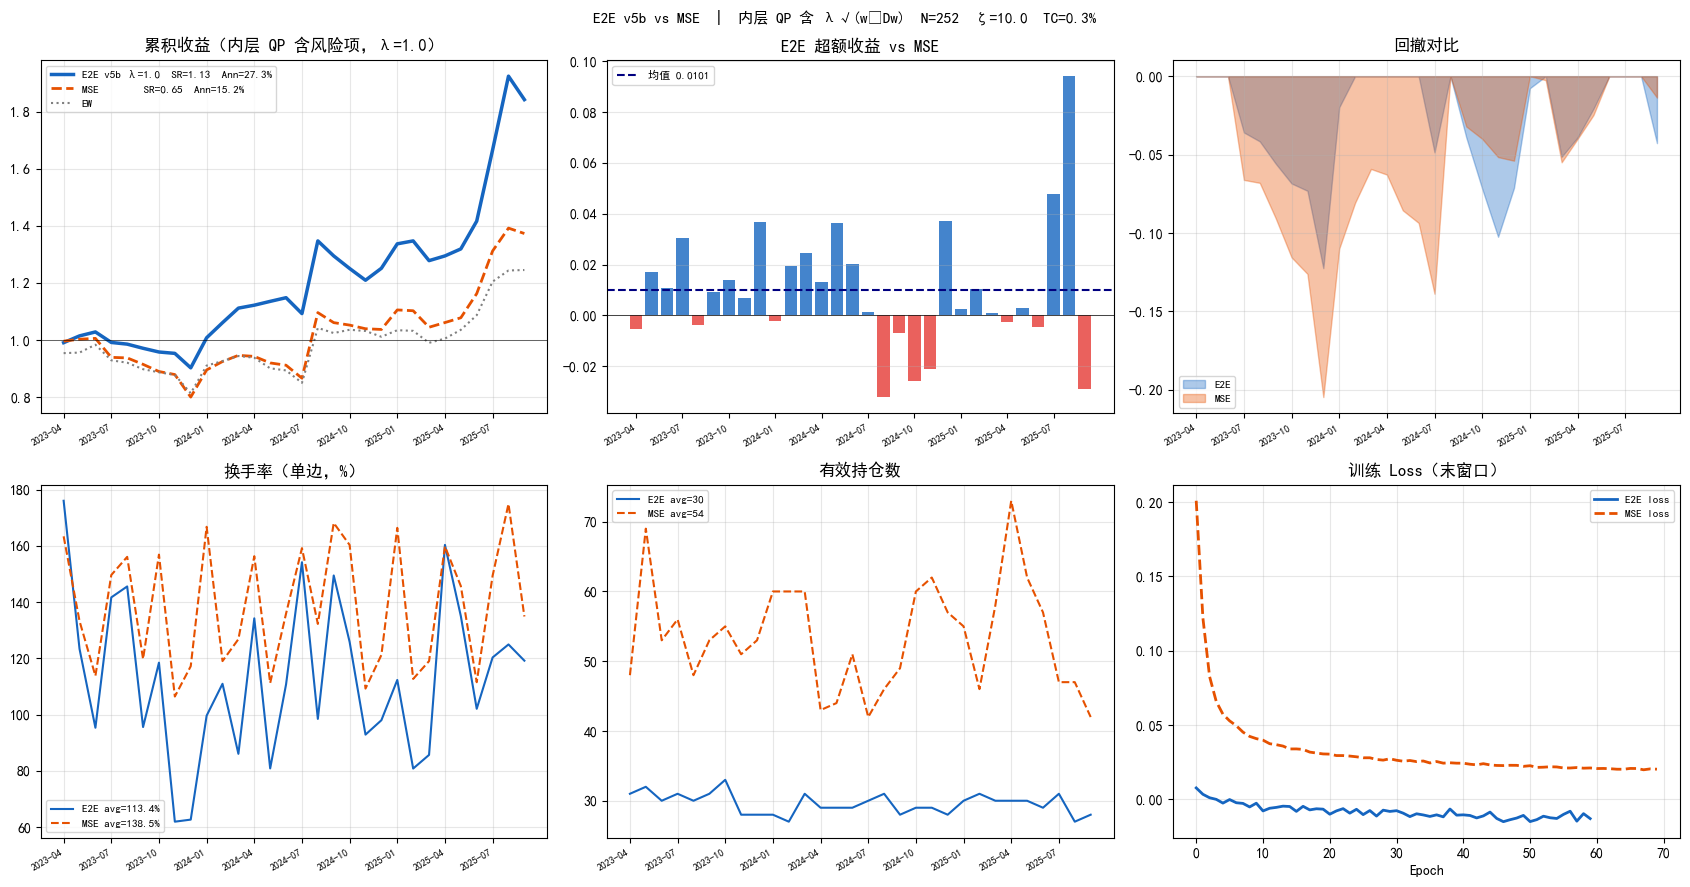

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


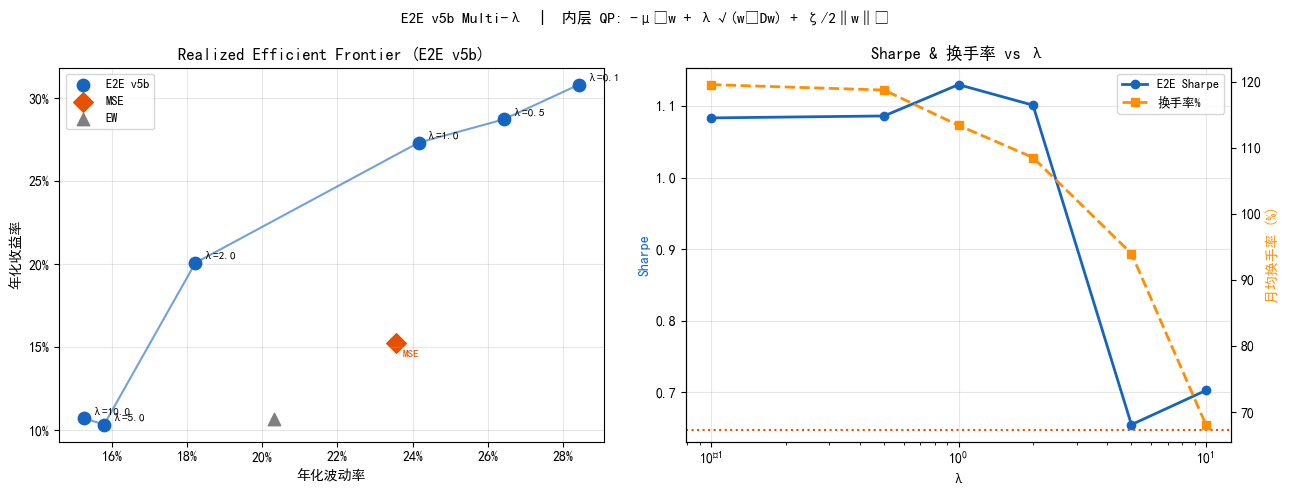

✓ 图表完毕


In [22]:
N_TEST  = len(r_e2e); x = np.arange(N_TEST)
dlabels = [d.strftime('%Y-%m') for d in res_e2e['dates']]
step    = max(1, N_TEST//8)
cum_e2e = np.cumprod(1+r_e2e); cum_mse = np.cumprod(1+r_mse); cum_bch = np.cumprod(1+r_bench)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

ax = axes[0,0]
ax.plot(cum_e2e, color='#1565C0', lw=2.5,
        label=f"E2E v5b λ={LAMBDA}  SR={m_e2e['Sharpe']:.2f}  Ann={m_e2e['Ann_Ret']:.1%}")
ax.plot(cum_mse, color='#E65100', lw=2, ls='--',
        label=f"MSE        SR={m_mse['Sharpe']:.2f}  Ann={m_mse['Ann_Ret']:.1%}")
ax.plot(cum_bch, color='gray', lw=1.5, ls=':', label='EW')
ax.axhline(1, color='k', lw=0.4); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title(f'累积收益（内层 QP 含风险项，λ={LAMBDA}）')
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[0,1]
excess = r_e2e - r_mse
ax.bar(x, excess, color=['#1565C0' if e>0 else '#E53935' for e in excess], alpha=0.8)
ax.axhline(excess.mean(), color='navy', ls='--', lw=1.5, label=f'均值 {excess.mean():.4f}')
ax.axhline(0, color='k', lw=0.5); ax.legend(fontsize=8)
ax.set_title('E2E 超额收益 vs MSE'); ax.grid(axis='y', alpha=0.3)
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

def dd_s(c): return (c/np.maximum.accumulate(c))-1
ax = axes[0,2]
ax.fill_between(x, 0, dd_s(cum_e2e), color='#1565C0', alpha=0.35, label='E2E')
ax.fill_between(x, 0, dd_s(cum_mse), color='#E65100', alpha=0.35, label='MSE')
ax.set_title('回撤对比'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1,0]
to_e2e = calc_turnover(res_e2e['weights']); to_mse = calc_turnover(res_mse['weights'])
ax.plot(to_e2e*100, color='#1565C0', lw=1.5, label=f'E2E avg={to_e2e.mean():.1%}')
ax.plot(to_mse*100, color='#E65100', lw=1.5, ls='--', label=f'MSE avg={to_mse.mean():.1%}')
ax.set_title('换手率（单边，%）'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1,1]
eff_e2e = [(w>0.001).sum() for w in res_e2e['weights']]
eff_mse = [(w>0.001).sum() for w in res_mse['weights']]
ax.plot(eff_e2e, color='#1565C0', lw=1.5, label=f'E2E avg={np.mean(eff_e2e):.0f}')
ax.plot(eff_mse, color='#E65100', lw=1.5, ls='--', label=f'MSE avg={np.mean(eff_mse):.0f}')
ax.set_title('有效持仓数'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xticks(x[::step]); ax.set_xticklabels(dlabels[::step], rotation=30, ha='right', fontsize=7)

ax = axes[1,2]
if res_e2e['loss_curves']: ax.plot(res_e2e['loss_curves'][-1], color='#1565C0', lw=2, label='E2E loss')
if res_mse['loss_curves']:  ax.plot(res_mse['loss_curves'][-1], color='#E65100', lw=2, ls='--', label='MSE loss')
ax.set_title('训练 Loss（末窗口）'); ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_xlabel('Epoch')

plt.suptitle(f'E2E v5b vs MSE  |  内层 QP 含 λ√(wᵀDw)  N={N}  ζ={ZETA_TRAIN}  TC=0.3%',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Efficient Frontier（多λ结果）──────────────────────────────────────────
if len(sweep_results) > 1:
    fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
    lam_vals = [l for l in LAMBDA_LIST if l in sweep_results]
    vols = [sweep_results[l]['metrics']['Ann_Vol'] for l in lam_vals]
    rets = [sweep_results[l]['metrics']['Ann_Ret'] for l in lam_vals]
    srs  = [sweep_results[l]['metrics']['Sharpe']  for l in lam_vals]
    tos  = [sweep_results[l]['metrics']['AvgTO']   for l in lam_vals]

    ax = axes2[0]
    ax.scatter(vols, rets, color='#1565C0', s=80, zorder=4, label='E2E v5b')
    ax.plot(vols, rets, color='#1565C0', lw=1.5, alpha=0.6)
    for l, v, r in zip(lam_vals, vols, rets):
        ax.annotate(f'λ={l}', (v,r), textcoords='offset points', xytext=(5,3), fontsize=8)
    ax.scatter([m_mse['Ann_Vol']], [m_mse['Ann_Ret']], color='#E65100', s=100, marker='D', label='MSE')
    ax.annotate('MSE', (m_mse['Ann_Vol'],m_mse['Ann_Ret']), textcoords='offset points', xytext=(5,-10), fontsize=8, color='#E65100')
    ax.scatter([m_bench['Ann_Vol']], [m_bench['Ann_Ret']], color='gray', s=80, marker='^', label='EW')
    ax.set_xlabel('年化波动率'); ax.set_ylabel('年化收益率')
    ax.set_title('Realized Efficient Frontier (E2E v5b)')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))

    ax = axes2[1]
    ln1 = ax.plot(lam_vals, srs, color='#1565C0', lw=2, marker='o', label='E2E Sharpe')
    ax2b = ax.twinx()
    ln2 = ax2b.plot(lam_vals, [t*100 for t in tos], color='#FF8F00', lw=2, ls='--', marker='s', label='换手率%')
    ax.axhline(m_mse['Sharpe'], color='#E65100', ls=':', lw=1.5, label=f'MSE SR={m_mse["Sharpe"]:.2f}')
    ax.set_xlabel('λ'); ax.set_ylabel('Sharpe', color='#1565C0')
    ax2b.set_ylabel('月均换手率 (%)', color='#FF8F00')
    ax.set_title('Sharpe & 换手率 vs λ')
    lns = ln1+ln2; ax.legend(lns, [l.get_label() for l in lns], fontsize=9)
    ax.grid(alpha=0.3); ax.set_xscale('log')

    plt.suptitle(f'E2E v5b Multi-λ  |  内层 QP: -μᵀw + λ√(wᵀDw) + ζ/2‖w‖²', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.show()
    print("✓ 图表完毕")
else:
    print("（多 λ 扫描未执行，跳过 Frontier 图）")